# Проект спринта 15: Модель поведенческого скоринга для банка "Ва-банк"

Выполнил: Артем Буров (DS12)  
Дата: 08.08.2026

## Описание проекта

**Банк «Ва‑банк»** — крупный розничный игрок с многомиллиардным кредитным портфелем: ежедневно в него поступают тысячи заявок, а совокупные активы исчисляются миллиардами рублей. При внешней стабильности бизнеса в сегменте потребительского кредитования нарастает скрытая угроза — волна просрочек, которая действует по принципу айсберга: видимая часть — это отдельные случаи задержек платежей, а основная опасность кроется в системных последствиях, способных серьёзно подорвать финансовую устойчивость.

**Ключевая проблема** — рост просроченной задолженности длительностью свыше 90 дней. По требованиям ЦБ банк обязан ежемесячно резервировать 100 % суммы таких проблемных кредитов, что приводит к масштабной заморозке капитала и сокращению свободных средств в обороте. Из‑за этого снижается ликвидность: резервы формируются за счёт прибыли, и банк вынужден ограничивать выдачу новых кредитов, теряя гибкость в управлении активами. Регуляторные риски дополнительно усиливают давление: несоблюдение нормативов грозит штрафами, предписаниями и даже отзывом лицензии. Поэтому своевременное выявление потенциально проблемных заёмщиков — это не просто инструмент оптимизации, а вопрос финансовой безопасности банка.

Действующие скоринговые модели оценивают риск только на этапе выдачи кредита и не позволяют отслеживать динамику платёжного поведения уже действующих клиентов: они не учитывают постепенное ухудшение финансового состояния, которое может проявиться спустя месяцы после получения займа. Именно поэтому банк нуждается в проактивном инструменте, который позволит заранее выявлять клиентов с высокой вероятностью серьёзной просрочки и управлять резервами и ликвидностью, избегая резких колебаний и непредвиденных потерь.

При этом данные имеют панельную структуру (клиент × месяц), а прогноз строится на горизонт в 12 месяцев — это требует строгого соблюдения временного порядка при разбиении выборки, чтобы исключить утечку информации из будущего. Ожидается значительный дисбаланс целевой переменной (просрочка ≥ 90 дней — относительно редкое событие), что диктует особый подход к выбору метрик качества и способам работы с классами. Кроме того, для банка критически важна интерпретируемость модели: выводы должны быть понятны не только аналитикам, но и регулятору — поэтому важно обеспечить возможность объяснения прогнозов на уровне признаков.

## Цель проекта

Предсказать вероятность того, что клиент банка совершит просрочку платежа по кредиту длительностью от 90 дней. Объект моделирования — клиент в конкретный месяц; целевая переменная — флаг, будет ли у клиента просрочка от 90 дней в течение ближайших 12 месяцев.

## Задача

Построить модель поведенческого скоринга, которая по данным о клиенте в выбранный месяц прогнозирует, возникнет ли у него просрочка на 90 дней или более. Каждая строка данных соответствует клиенту в конкретном месяце. Целевая переменная принимает значение 1, если в ближайшие 12 месяцев у клиента появляется просрочка длиной от 90 дней, и 0 — если такой просрочки не возникает.

---
---
## ???????????????? Перевод бизнес-задачи на язык машинного обучения

* Напишите, что конкретно будете делать, пользуясь терминами машинного обучения:
  * какие модели будете использовать;
  * какие методы работы с данными применять;
  * как планируете решать поставленную задачу.


Ваша задача — не «выжать максимум» из одной метрики, а сбалансировать сразу три ключевых показателя качества:
Approval rate показывает, какую долю клиентов модель готова считать надёжными, что влияет на объём доступных банку средств.​
Default rate отражает, какой уровень фактических дефолтов происходит в группе клиентов, признанных банком надёжными.​
Missed defaults rate — это доля дефолтов, которую модель пропускает, не замечая риска.​
Оптимальная модель — это компромисс между числом надёжных клиентов и контролем риска. Нужно подобрать порог классификации, при котором портфель безопасных кредитов объёмен, а его качество остаётся приемлемым: без превышений заданного уровня дефолтов и количества незамеченных проблемных клиентов. Необходимый уровень каждой из метрик указан в требованиях к решению.

---
---



## Метрики

### Recall («полнота»)

Метрика показывает, какую долю объектов класса 1 модель смогла корректно предсказать. В задаче поведенческого скоринга это доля клиентов с высоким риском дефолта, которых удалось определить.

#### Формула расчёта

$$
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$

Где:

- **TP** — количество клиентов, которых модель посчитала рискованными (присвоила им класс 1) и у которых действительно случился дефолт.
- **FN** — количество клиентов, которых модель посчитала надёжными (присвоила им класс 0), но у них случился дефолт.

#### Интерпретация

- **Высокое значение Recall** означает, что модель корректно предсказывает дефолт для подавляющего большинства клиентов в зоне риска — банк «видит» почти всех проблемных заёмщиков.
- **Низкое значение метрики** сигнализирует о том, что многие потенциальные неплательщики остались незамеченными: это критично для банка, так как ведёт к недорезервированию и регуляторным рискам.
___

## Precision («точность»)

Метрика показывает, какая доля объектов, которым был присвоен класс 1, действительно к нему относится. В бизнес‑контексте проекта precision покажет, какую долю клиентов, помеченных как рискованные, составляют действительно проблемные заёмщики.

#### Формула расчёта

$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
$$

Где:

- **TP** — количество клиентов, которых модель посчитала рискованными (присвоила им класс 1) и у которых действительно случился дефолт.
- **FP** — количество клиентов, которых модель посчитала рискованными (присвоила им класс 1), но у которых дефолт не случился.

### Интерпретация

- **Высокое значение Precision** означает, что среди тех клиентов, которых модель пометила как рискованных, почти все действительно ушли в дефолт.
- **Низкое значение метрики** означает, что среди клиентов, которых модель определяет в зону риска, много тех, кто на самом деле выплачивает платежи вовремя.

___

### Approval rate («уровень одобрения»)

Метрика показывает долю клиентов, которых модель считает надёжными — не видит у них риска дефолта. Она позволяет оценить, скольким клиентам будет присвоен класс 0 при оценке риска просрочки.

#### Формула расчёта

$$
\text{Approval rate} = \frac{\text{FN} + \text{TN}}{\text{N}}
$$

Где:

- **FN** — количество клиентов, которых модель посчитала надёжными (присвоила им класс 0), но у них случился дефолт.
- **TN** — количество клиентов, которых модель посчитала надёжными (присвоила им класс 0) и у которых дефолта не случилось.
- **N** — размер всей выборки заявок или текущих заёмщиков.

#### Интерпретация

**Высокое значение approval rate** означает, что модель даёт одобрение большому количеству клиентов — то есть предполагает, что просрочек не будет. Бизнес будет рад такому сценарию, если модель действительно корректно определяет надёжных клиентов. Однако это создаёт риски: если модель слабая, при таком уровне одобрений много рискованных клиентов останутся незамеченными. Банку будет казаться, что всё в порядке, но накопленный риск может обнаружиться позже.

**Низкое значение approval rate** означает, что модель одобряет только самых надёжных заёмщиков. Круг клиентов получается безопасным, но такой подход сильно урезает объём бизнеса: банк сознательно жертвует доходом, так как часть платёжеспособных клиентов получает отказ. Из‑за этого часть денег банка не попадёт в оборот, и потенциал прибыли не реализуется.

___

### Default rate («доля просрочек платежа»)

Метрика показывает, какая часть клиентов среди тех, кого модель посчитала надёжными, в итоге всё‑таки не заплатила по своим обязательствам. Другими словами, это доля клиентов среди одобренных моделью, которые всё‑таки ушли в дефолт.

#### Формула расчёта

$$
\text{Default rate} = \frac{\text{FN}}{\text{FN} + \text{TN}}
$$

Где:

- **FN** — количество клиентов, которых модель посчитала надёжными (класс 0), но у них случился дефолт.
- **TN** — количество клиентов, которых модель посчитала надёжными (класс 0) и у которых дефолта не случилось.

#### Интерпретация

- **Высокое значение Default rate** означает, что внутри группы заёмщиков, которая считается надёжной и получает одобрение, заметная доля клиентов всё‑таки попадает в дефолт. Формально модель выглядит «мягкой»: она даёт много одобрений, но среди них сидит слишком много будущих проблемных клиентов.
- **Низкое значение Default rate** означает, что среди тех, кого модель обозначила как надёжных, почти все действительно платят. Такая модель мало ошибается, и её прогнозы относительно безопасны для банка.

___

### Missed defaults rate («доля пропущенных дефолтов»)

Метрика показывает, какую долю от всех проблемных клиентов модель не заметила — то есть посчитала этих клиентов надёжными и пропустила дальше, хотя они в итоге не заплатили.

### Формула расчёта

$$
\text{Missed defaults rate} = \frac{\text{FN}}{\text{FN} + \text{TP}}
$$

Также Missed defaults rate можно выразить как $1 - \text{Recall}$.

Где:

- **FN** — количество клиентов, которых модель посчитала надёжными (класс 0), но у них случился дефолт.
- **TP** — количество клиентов, которых модель посчитала рискованными (класс 1) и у которых действительно случился дефолт.

#### Интерпретация

- **Высокое значение Missed defaults rate** означает, что модель отмечает заметную долю будущих неплательщиков как надёжных клиентов. Для банка это создаёт опасную ситуацию: формально всё будет спокойно, но внутри множества одобренных клиентов будет расти количество рискованных заёмщиков — это проявится позже в виде просрочек и списаний. Чем выше эта метрика, тем больше дефолтов будет пропускать банк.
- **Низкое значение Missed defaults rate** означает, что из всех клиентов, которые в итоге ушли в дефолт, лишь небольшая часть была отмечена моделью как надёжные. Большинство проблемных случаев модель отфильтровывает.

___




## Описание источников данных

Таблица 1. Данные о просрочке платежа (`ds_15_loan_payment_credit.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `дата_начала_периода` | Дата начала периода просрочки |
| `просрочка_дней` | Длительность просрочки в днях |

---

Таблица 2. Месячные транзакции клиента (`ds_15_transactions.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `date` | Календарная дата (по месяцам) |
| `MCC_5300` | Помесячные траты по MCC‑коду 5300 |
| `MCC_5814` | Помесячные траты по MCC‑коду 5814 |
| `MCC_5812` | Помесячные траты по MCC‑коду 5812 |
| `MCC_5411` | Помесячные траты по MCC‑коду 5411 |
| `MCC_3990` | Помесячные траты по MCC‑коду 3990 |
| `MCC_5722` | Помесячные траты по MCC‑коду 5722 |
| `MCC_4900` | Помесячные траты по MCC‑коду 4900 |
| `MCC_другое` | Помесячные траты по остальным MCC‑кодам |

---

Таблица 3. Описание клиента на момент регистрации в банке (`ds_15_client_description.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `возраст` | Возраст клиента |
| `семейное_положение` | Семейное положение: «разведённые», «есть семья», «нет семьи» |
| `наличие_иждивенцев` | Наличие лиц на финансовом попечении: `1` — да, `0` — нет |
| `дата_регистрации` | Дата начала взаимоотношений банка и клиента |

---

Таблица 4. Описание кредита (`ds_15_credit_description.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `доход` | Месячный доход клиента на момент взятия кредита (руб.) |
| `сумма_кредита` | Сумма выданного кредита (руб.) |

---

Таблица 5. Данные о наличии ипотеки (`ds_15_mortgage_presence.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `дата_открытия` | Дата оформления ипотеки |
| `наличие_ипотеки` | Наличие ипотеки: `1` — да, `0` — нет |

---

Таблица 6. Данные о кредитном рейтинге клиента (`ds_15_credit_rating.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `date` | Дата получения рейтинга из внешнего источника |
| `кредитный_рейтинг` | Значение рейтинга на указанную дату |

---

Таблица 7. Данные о макроэкономических показателях России (`ds_15_macro_data.csv`)
| Столбец | Описание |
| --- | --- |
| `date` | Месяц и год, на которые актуальны показатели |
| `учетная_ставка` | Учётная ставка (в %) |
| `уровень_безработицы` | Уровень безработицы (в %) |
| `инфляция` | Инфляция (в %) |

---

Таблица 8. Данные о дате проведения поведенческого скоринга (`ds_15_cohort_grid.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `score_date` | Дата скоринга |
---




## 1. Подготовка рабочего пространства

### 1.1 Загрузка необходимых библиотек

In [58]:
# Загружаем базовые библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Системные библиотеки, настройки отображения датафреймов и предупредительных сообщений
# import joblib
import os
import re
import cyrtranslit
# import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

# warnings.filterwarnings('ignore', category=FutureWarning)
# warnings.filterwarnings('ignore', category=UserWarning)
# warnings.filterwarnings('ignore', category=DeprecationWarning)

path = os.getcwd()
RANDOM_SEED = 555

### 1.2 Подготовка классов и функций

In [126]:
# Подготавливаем функции визуализации данных и расчета метрик

# =========================
# Функция оптимизации датафрейма

def optimize_dataframe(df: pd.DataFrame) -> pd.DataFrame:

    # 0. Функция формирования уникальных имён (на случай дублей после транслитерации)
    def make_unique_columns(cols):
        seen = {}
        new_cols = []
        for c in cols:
            if c not in seen:
                seen[c] = 1
                new_cols.append(c)
            else:
                seen[c] += 1
                new_cols.append(f"{c}_{seen[c]}")
        return new_cols

    # 1. Транслитерация кириллицы в латиницу
    def translit_col(col):
        return cyrtranslit.to_latin(str(col), 'ru')

    df.columns = df.columns.map(translit_col)

    # 2. Приводим к нижнему регистру
    df.columns = df.columns.astype(str).str.lower()

    # 3. Убираем апострофы и кавычки отдельно (это частая проблема cyrtranslit)
    df.columns = df.columns.str.replace(r"['\"‘’`]", "", regex=True)

    # 4. Заменяем любые не-буквенно-цифровые символы (кроме подчёркивания) на _
    df.columns = df.columns.str.replace(r'[^a-z0-9_]', '_', regex=True)

    # 5. Схлопываем множественные подчёркивания и убираем их по краям
    df.columns = df.columns.str.replace(r'_+', '_', regex=True).str.strip('_')

    # 6. Защита от пустых имён колонок
    empty_cols = df.columns == ''
    if empty_cols.any():
        for i, col in enumerate(df.columns):
            if col == '':
                df.columns.values[i] = f'col_{i}'

    # 7. Делаем имена уникальными (на случай дублей после транслитерации)
    df.columns = make_unique_columns(df.columns)

    # 8. Оптимизация типов float
    float_cols = df.select_dtypes(include=['float64', 'float32']).columns
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')

    # 9. Оптимизация типов int
    int_cols = df.select_dtypes(include=['int64', 'int32']).columns
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    return df


# =========================
# Анализ пропущенных значений

def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': df.isnull().mean()
    }).sort_values(by='Кол-во пропусков', ascending=False)
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        print("Пропусков в данных нет")
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))


# ========================
# histogram
def histogram_chart(df, attr='Признак', bins=10, kde=True, figsize=(10,6), title_text='Распределение признака', ylabel='Количество'):
    _, ax = plt.subplots(figsize=figsize)
    sns.histplot(data=df, x=attr, bins=bins, ax=ax, kde=kde)
    plt.title(title_text)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.5)
    median_val = df[attr].median()
    mean_val = df[attr].mean()
    plt.axvline(median_val, color='red', linestyle='--', label=f'Медиана: {median_val:.1f}')
    plt.axvline(mean_val, color='purple', linestyle='-.', label=f'Средняя: {mean_val:.1f}')
    plt.legend()
    plt.show()

# =========================
# boxplot
def boxplot_chart(df, feature_list, diagram_name='Диаграммы размаха значений количественных признаков'):
    n_plots = len(feature_list)
    _, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(12, 2 * n_plots), squeeze=False)
    
    for i, feature in enumerate(feature_list):
        df[feature].plot.box(ax=axes[i, 0], vert=False)
        axes[i, 0].set_title(f'Boxplot: {feature}')
        axes[i, 0].tick_params(axis='x', labelrotation=0)
        axes[i, 0].grid(axis='x', alpha=0.5)

    plt.suptitle(diagram_name, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

# =========================
# Line time series chart
def plot_line_time_series(df, date_col='date', cat_cols=None, title='Динамика', legend_title='Категории', ylabel='Сумма', figsize=(14, 7), rot=45):
    # Забираем числовые признаки, если на входе cat_cols=None
    if cat_cols is None:
        cat_cols = df.select_dtypes(include='float').columns.to_list()
    
    # Копируем, чтобы не менять исходный DataFrame
    temp_df = df[[date_col] + cat_cols].copy()
    
    # Преобразуем дату в datetime
    temp_df[date_col] = pd.to_datetime(temp_df[date_col], errors='coerce')
    
    # Агрегируем по месяцам: суммируем траты по всем клиентам за каждый месяц
    monthly_agg = temp_df.groupby(date_col)[cat_cols].sum()
    
    plt.figure(figsize=figsize)
    for col in cat_cols:
        plt.plot(monthly_agg.index, monthly_agg[col], label=col)
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Дата (месяц)', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.xticks(rotation=rot)
    plt.tight_layout()
    plt.show()

# =========================
# bar chart
def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Количество',
    title='Столбчатая диаграмма',
    top_n=5
):

    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    plt.figure(figsize=figsize)

    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(value_counts):
        y_offset = 0.001 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    for i, v in enumerate(value_counts_normalized):
        y_pos = (v * total) / 2
        ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )

    plt.tight_layout()

    plt.show()


## 2. Загрузка данных

In [ ]:
hlink = 'https://code.s3.yandex.net/datasets/'

# Загрузка и оптимизация каждого датафрейма отдельно
df0_loan_payment_credit = optimize_dataframe(pd.read_csv(hlink + 'ds_15_loan_payment_credit.csv'))
df0_transactions = optimize_dataframe(pd.read_csv(hlink + 'ds_15_transactions.csv'))
df0_client_description = optimize_dataframe(pd.read_csv(hlink + 'ds_15_client_description.csv'))
df0_credit_description = optimize_dataframe(pd.read_csv(hlink + 'ds_15_credit_description.csv'))
df0_mortgage_presence = optimize_dataframe(pd.read_csv(hlink + 'ds_15_mortgage_presence.csv'))
df0_credit_rating = optimize_dataframe(pd.read_csv(hlink + 'ds_15_credit_rating.csv'))
df0_macro_data = optimize_dataframe(pd.read_csv(hlink + 'ds_15_macro_data.csv'))
df0_cohort_grid = optimize_dataframe(pd.read_csv(hlink + 'ds_15_cohort_grid.csv'))

# Соберем все датафреймы в один словарь
dfs = {
    'loan_payment_credit': df0_loan_payment_credit,
    'transactions': df0_transactions,
    'client_description': df0_client_description,
    'credit_description': df0_credit_description,
    'mortgage_presence': df0_mortgage_presence,
    'credit_rating': df0_credit_rating,
    'macro_data': df0_macro_data,
    'cohort_grid': df0_cohort_grid,
}

print("Все датафреймы загружены и оптимизированы")


Все датафреймы загружены и оптимизированы


### Таблица 1. Данные о просрочке платежа

In [5]:
# Проверим первые 5 строк
df0_loan_payment_credit.head()

,id,data_nachala_perioda,prosrochka_dnej
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


In [6]:
# Структура датафрейма и типы данных
df0_loan_payment_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   id                    5500 non-null   str  
 1   data_nachala_perioda  5500 non-null   str  
 2   prosrochka_dnej       5500 non-null   int16
dtypes: int16(1), str(2)
memory usage: 96.8 KB


In [7]:
# Через describe нужно определить есть ли дубликаты по первичному ключу (PK) - id
# id - является PK
df0_loan_payment_credit.astype('str').describe()

,id,data_nachala_perioda,prosrochka_dnej
count,5500,5500,5500
unique,5500,73,71
top,IDF55109846,2018-12-01,138
freq,1,209,97


### Таблица 2. Месячные транзакции клиента

In [8]:
# Проверим первые 5 строк
df0_transactions.head()

,id,date,mcc_5300,mcc_5814,mcc_5812,mcc_5411,mcc_3990,mcc_5722,mcc_4900,mcc_drugoe
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.760010,2156.67,1519.46,4352.90


In [9]:
# Структура датафрейма и типы данных
df0_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          577494 non-null  str    
 1   date        577494 non-null  str    
 2   mcc_5300    577494 non-null  float64
 3   mcc_5814    577494 non-null  float64
 4   mcc_5812    577494 non-null  float64
 5   mcc_5411    577494 non-null  float64
 6   mcc_3990    577494 non-null  float32
 7   mcc_5722    577494 non-null  float64
 8   mcc_4900    577494 non-null  float64
 9   mcc_drugoe  577494 non-null  float64
dtypes: float32(1), float64(7), str(2)
memory usage: 41.9 MB


In [10]:
# Через describe определим статус поля id
# id - это внешний ключ FK
df0_transactions[['id', 'date']].describe()

,id,date
count,577494,577494
unique,13500,84
top,IDF55014574,2019-12-01
freq,84,13500


### Таблица 3. Описание клиента на момент регистрации в банке

In [11]:
# Проверим первые 5 строк
df0_client_description.head()

,id,vozrast,semejnoe_polozhenie,nalichie_izhdivenczev,data_registraczii
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01


In [12]:
# Структура датафрейма и типы данных
df0_client_description.info()

<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id                     13500 non-null  str  
 1   vozrast                13500 non-null  int8 
 2   semejnoe_polozhenie    13500 non-null  str  
 3   nalichie_izhdivenczev  13500 non-null  int8 
 4   data_registraczii      13500 non-null  str  
dtypes: int8(2), str(3)
memory usage: 342.9 KB


In [13]:
# Через describe нужно определить есть ли дубликаты по первичному ключу (PK) - id
# id - является PK
df0_client_description.astype('str').describe()

,id,vozrast,semejnoe_polozhenie,nalichie_izhdivenczev,data_registraczii
count,13500,13500,13500,13500,13500
unique,13500,52,3,2,84
top,IDF55109846,19,нет семьи,0,2014-03-01
freq,1,357,4584,6956,189


### Таблица 4. Описание кредита

In [14]:
# Проверим первые 5 строк
df0_credit_description.head()

,id,dohod,summa_kredita
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870


In [15]:
# Структура датафрейма и типы данных
df0_credit_description.info()

<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             13500 non-null  str  
 1   dohod          13500 non-null  int32
 2   summa_kredita  13500 non-null  int32
dtypes: int32(2), str(1)
memory usage: 211.1 KB


In [16]:
# Через describe нужно определить есть ли дубликаты по первичному ключу (PK) - id
# id - является PK
df0_credit_description['id'].describe().to_frame()

,id
count,13500
unique,13500
top,IDF55109846
freq,1


### Таблица 5. Данные о наличии ипотеки

In [17]:
# Проверим первые 5 строк
df0_mortgage_presence.head()

,id,data_otkrytiya,nalichie_ipoteki
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1


In [18]:
# Структура датафрейма и типы данных
df0_mortgage_presence.info()

<class 'pandas.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                6609 non-null   str  
 1   data_otkrytiya    6609 non-null   str  
 2   nalichie_ipoteki  6609 non-null   int8 
dtypes: int8(1), str(2)
memory usage: 109.8 KB


In [19]:
# Через describe нужно определить есть ли дубликаты по первичному ключу (PK) - id
# id - является PK
df0_mortgage_presence.astype('str').describe()

,id,data_otkrytiya,nalichie_ipoteki
count,6609,6609,6609
unique,6609,84,1
top,IDF54896351,2018-12-01,1
freq,1,98,6609


### Таблица 6. Данные о кредитном рейтинге клиента

In [20]:
# Проверим первые 5 строк
df0_credit_rating.head()

,id,date,kreditnyj_rejting
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688


In [21]:
# Структура датафрейма и типы данных
df0_credit_rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   id                 577494 non-null  str  
 1   date               577494 non-null  str  
 2   kreditnyj_rejting  577494 non-null  int16
dtypes: int16(1), str(2)
memory usage: 9.9 MB


In [22]:
# Через describe определим статус поля id
# id - это внешний ключ FK
df0_credit_rating.astype('str').describe()

,id,date,kreditnyj_rejting
count,577494,577494,577494
unique,13500,84,510
top,IDF55014574,2019-12-01,582
freq,84,13500,3612


### Таблица 7. Данные о макроэкономических показателях России

In [23]:
# Проверим первые 5 строк
df0_macro_data.head()

,date,uchetnaya_stavka,uroven_bezraboticzy,inflyacziya
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


In [24]:
# Структура датафрейма и типы данных
df0_macro_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 84 non-null     str    
 1   uchetnaya_stavka     84 non-null     float32
 2   uroven_bezraboticzy  84 non-null     float32
 3   inflyacziya          84 non-null     float32
dtypes: float32(3), str(1)
memory usage: 1.8 KB


In [25]:
# date - является PK
df0_macro_data.astype('str').describe()

,date,uchetnaya_stavka,uroven_bezraboticzy,inflyacziya
count,84,84,84,84
unique,84,40,18,62
top,2013-01-01,5.5,5.1,0.35
freq,1,14,8,3


### Таблица 8. Данные о дате проведения поведенческого скоринга

In [26]:
# Проверим первые 5 строк
df0_cohort_grid.head()

,id,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


In [27]:
# Структура датафрейма и типы данных
df0_cohort_grid.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   id          577494 non-null  str  
 1   score_date  577494 non-null  str  
dtypes: str(2)
memory usage: 8.8 MB


In [28]:
# Через describe определим статус поля id
# id - это внешний ключ FK
df0_cohort_grid.describe()

,id,score_date
count,577494,577494
unique,13500,84
top,IDF55014574,2019-12-01
freq,84,13500


## Комментарий по итогам загрузки данных

Все датасеты успешно загружены и оптимизированы функцией `optimize_dataframe`. Пропусков в данных нет — по всем колонкам во всех таблицах количество непустых значений совпадает с общим числом строк.



**Краткая сводка по датасетам**

| Датасет | Тип ключа | Число записей | Основные типы данных | Особенности |
| --- | --- | --- | --- | --- |
| `df0_loan_payment_credit` | `id` — PK | 5 500 | `str`, `int16` | Данные о просрочках; компактный набор |
| `df0_transactions` | `id` — FK | 577 494 | `str`, `float32/float64` | Наибольший по объёму датасет (транзакции) |
| `df0_client_description` | `id` — PK | 13 500 | `str`, `int8` | Основной справочник клиентов |
| `df0_credit_description` | `id` — PK | 13 500 | `str`, `int32` | Кредитные параметры на момент выдачи |
| `df0_mortgage_presence` | `id` — PK | 6 609 | `str`, `int8` | Наличие ипотеки и дата открытия |
| `df0_credit_rating` | `id` — FK | 577 494 | `str`, `int16` | Рейтинги по клиентам |
| `df0_macro_data` | `date` — PK | 84 | `str`, `float32` | Макропоказатели (месячные) |
| `df0_cohort_grid` | `id` — FK | 577 494 | `str` | Даты скоринга |



**Ключевые метрики по клиентам**

- Общее число уникальных клиентов (по `df0_client_description`, который выступает основным справочником): **13 500**.
- Число клиентов, имевших кредит (по `df0_credit_description`): **13 500** — все клиенты из справочника имели/имеют кредит.
- Число клиентов с данными о просрочке платежа (в `df0_loan_payment_credit`): **5 500**. Есть данные по **40,7 %** клиентов ($5\ 500 / 13\ 500$).
- Число клиентов с ипотекой (по `df0_mortgage_presence`): **6 609**. То есть ипотека есть примерно у **49 %** клиентов ($6\ 609 / 13\ 500$).



**Важные наблюдения для дальнейшего объединения**

- В таблицах `df0_transactions`, `df0_credit_rating`, `df0_cohort_grid` число строк (577 494) существенно превышает число клиентов (13 500), что логично: это данные в разрезе времени (даты). При объединении потребуется учитывать временной ключ (`date`/`score_date`) и тип соединения (скорее всего, `left` или `inner` с последующей группировкой).
- Таблица `df0_macro_data` не содержит `id` клиента — она будет присоединяться по дате (после приведения к единому формату) и служить источником макропризнаков.
- Все числовые признаки уже приведены к оптимизированным типам (`int8`, `int16`, `float32`), что экономит память и ускорит последующие операции (в том числе кросс‑валидацию и подбор гиперпараметров).



**Общий вывод**

Датасеты готовы к этапу объединения и построения признаков:

- Нет пропусков, которые могли бы исказить метрики.
- Чётко выделены PK/FK, понятна логика связей.
- Есть достаточный объём транзакционных и рейтинговых данных для построения временных признаков.
- Оптимизированные типы данных позволят эффективно работать с пайплайнами, не теряя производительности.
---


## ER диаграмма

```mermaid

erDiagram
    df0_client_description {
        string id PK
        int8 vozrast
        string semejnoe_polozhenie
        int8 nalichie_izhdivenczev
        string data_registraczii
    }

    df0_credit_description {
        string id FK
        int32 dohod
        int32 summa_kredita
    }

    df0_loan_payment_credit {
        string id FK
        string data_nachala_perioda
        int16 prosrochka_dnej
    }

    df0_mortgage_presence {
        string id FK
        string data_otkrytiya
        int8 nalichie_ipoteki
    }

    df0_transactions {
        string id FK
        string date
        float mcc_5300
        float mcc_5814
        float mcc_5812
        float mcc_5411
        float mcc_3990
        float mcc_5722
        float mcc_4900
        float mcc_drugoe
    }

    df0_credit_rating {
        string id FK
        string date
        int16 kreditnyj_rejting
    }

    df0_cohort_grid {
        string id FK
        string score_date
    }

    df0_macro_data {
        string date PK
        float uchetnaya_stavka
        float uroven_bezraboticzy
        float inflyacziya
    }

    df0_client_description ||--o{ df0_credit_description : "1:N"
    df0_client_description ||--o{ df0_loan_payment_credit : "1:N"
    df0_client_description ||--o{ df0_mortgage_presence : "1:N"
    df0_client_description ||--o{ df0_transactions : "1:N"
    df0_client_description ||--o{ df0_credit_rating : "1:N"
    df0_client_description ||--o{ df0_cohort_grid : "1:N"

    df0_transactions }|--|| df0_macro_data : "N:1 по date"
    df0_credit_rating }|--|| df0_macro_data : "N:1 по date"
    df0_cohort_grid }|--|| df0_macro_data : "N:1 по score_date → date"
```

---

#

## 3. Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

### 3.1 Проверка на наличие явных дубликатов

In [41]:
count = 0
for df_name, df_ in dfs.items():
    d = df_.duplicated().sum() 
    if d > 0:
        count += 1
    print(f'Начичие явных дубликатов {df_name}: {d}')

print('='*60)
print()

if count > 0:
    print('Обнаружены явные дубликаты')
else:
    print('Явные дубликаты не обнаружены')

Начичие явных дубликатов loan_payment_credit: 0
Начичие явных дубликатов transactions: 0
Начичие явных дубликатов client_description: 0
Начичие явных дубликатов credit_description: 0
Начичие явных дубликатов mortgage_presence: 0
Начичие явных дубликатов credit_rating: 0
Начичие явных дубликатов macro_data: 0
Начичие явных дубликатов cohort_grid: 0

Явные дубликаты не обнаружены


### 3.2 Проверка пропусков

In [52]:
for df_name, df_ in dfs.items():
    print(f'Проверка наличия пропусков в {df_name}:', end=' ')
    show_missing_stats(df_)

Проверка наличия пропусков в loan_payment_credit: Пропусков в данных нет
Проверка наличия пропусков в transactions: Пропусков в данных нет
Проверка наличия пропусков в client_description: Пропусков в данных нет
Проверка наличия пропусков в credit_description: Пропусков в данных нет
Проверка наличия пропусков в mortgage_presence: Пропусков в данных нет
Проверка наличия пропусков в credit_rating: Пропусков в данных нет
Проверка наличия пропусков в macro_data: Пропусков в данных нет
Проверка наличия пропусков в cohort_grid: Пропусков в данных нет


### 3.3 Данные о просрочке платежа: loan_payment_credit

In [53]:
df0_loan_payment_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   id                    5500 non-null   str  
 1   data_nachala_perioda  5500 non-null   str  
 2   prosrochka_dnej       5500 non-null   int16
dtypes: int16(1), str(2)
memory usage: 96.8 KB


In [56]:
print('Первая дата периода:', df0_loan_payment_credit.data_nachala_perioda.min())
print('последняя дата периода:', df0_loan_payment_credit.data_nachala_perioda.max())

Первая дата периода: 2013-11-01
последняя дата периода: 2019-12-01


In [57]:
df0_loan_payment_credit.prosrochka_dnej.describe()

count    5500.000000
mean      114.748000
std        20.362422
min        80.000000
25%        97.000000
50%       115.000000
75%       132.000000
max       150.000000
Name: prosrochka_dnej, dtype: float64

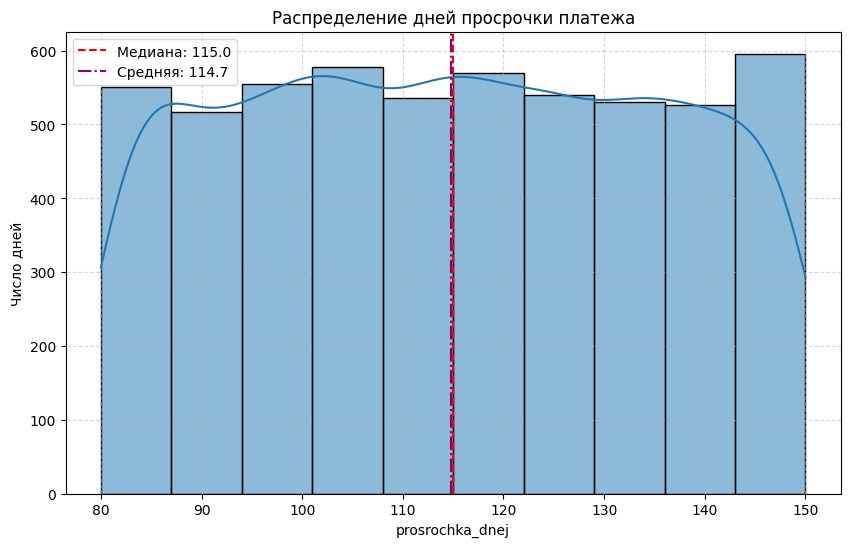

In [ ]:
histogram_chart(df=df0_loan_payment_credit, attr='prosrochka_dnej', bins=10, title_text='Распределение дней просрочки платежа', ylabel='Число дней')

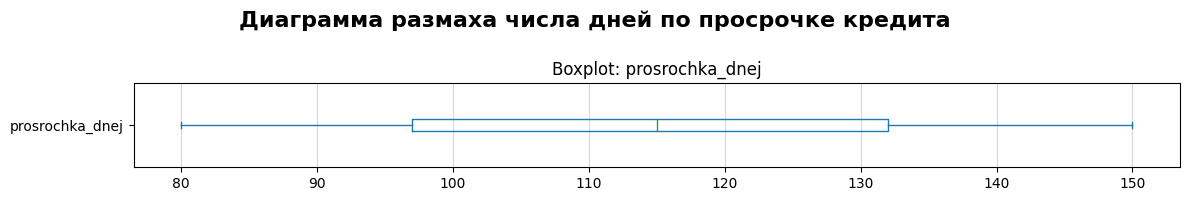

In [76]:
boxplot_chart(df=df0_loan_payment_credit, feature_list=['prosrochka_dnej'], diagram_name='Диаграмма размаха числа дней по просрочке кредита')

### 3.4 Транзакции клиента: transactions

In [70]:
df0_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          577494 non-null  str    
 1   date        577494 non-null  str    
 2   mcc_5300    577494 non-null  float64
 3   mcc_5814    577494 non-null  float64
 4   mcc_5812    577494 non-null  float64
 5   mcc_5411    577494 non-null  float64
 6   mcc_3990    577494 non-null  float32
 7   mcc_5722    577494 non-null  float64
 8   mcc_4900    577494 non-null  float64
 9   mcc_drugoe  577494 non-null  float64
dtypes: float32(1), float64(7), str(2)
memory usage: 41.9 MB


In [71]:
print('Первая дата периода:', df0_transactions.date.min())
print('последняя дата периода:', df0_transactions.date.max())

Первая дата периода: 2013-01-01
последняя дата периода: 2019-12-01


In [72]:
df0_transactions.describe()

,mcc_5300,mcc_5814,mcc_5812,mcc_5411,mcc_3990,mcc_5722,mcc_4900,mcc_drugoe
count,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000
mean,6177.123479,3507.682295,2993.862550,9263.099506,1128.116821,3604.437043,3682.487182,5414.896895
std,8835.871514,5710.755226,4541.119582,12299.732992,1557.157471,5005.896972,5567.979383,7190.882383
min,162.910000,62.180000,67.060000,286.110000,31.900000,108.400000,81.290000,166.260000
25%,1360.880000,583.480000,611.540000,2139.480000,245.059998,824.942500,700.632500,1250.850000
50%,2659.590000,1233.110000,1224.530000,4115.385000,476.890015,1590.120000,1397.065000,2398.330000
75%,6561.467500,3642.392500,3201.612500,9287.545000,1159.520020,3866.050000,3872.412500,5413.530000
max,86939.400000,55720.690000,47969.570000,101301.950000,14261.490234,54630.190000,52987.530000,60033.550000


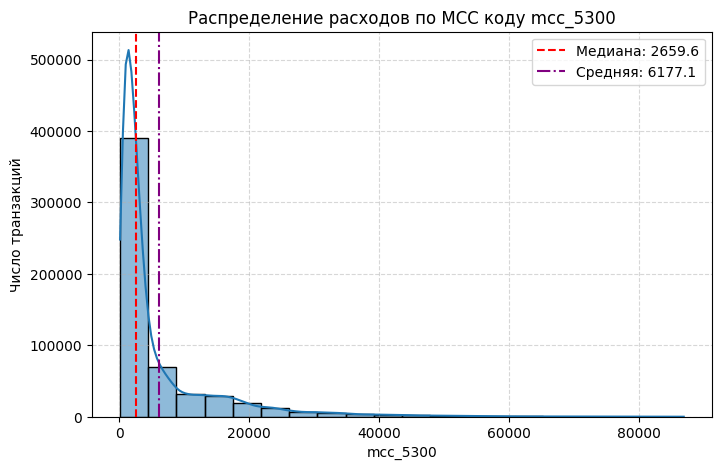

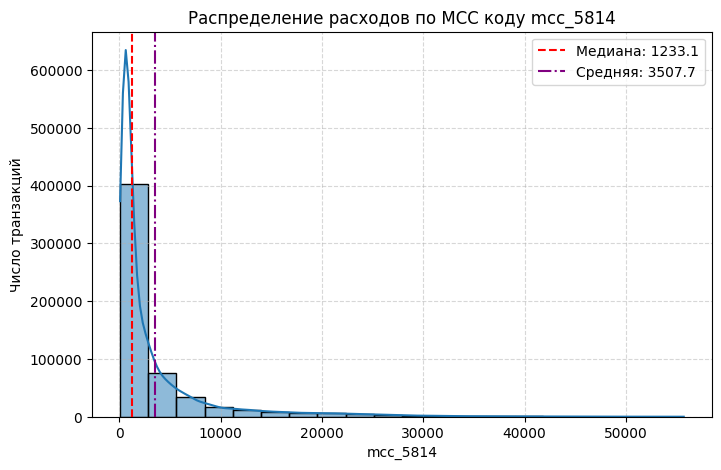

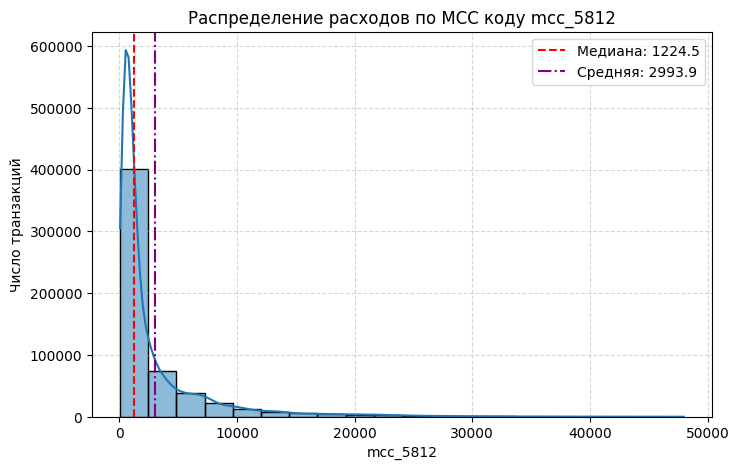

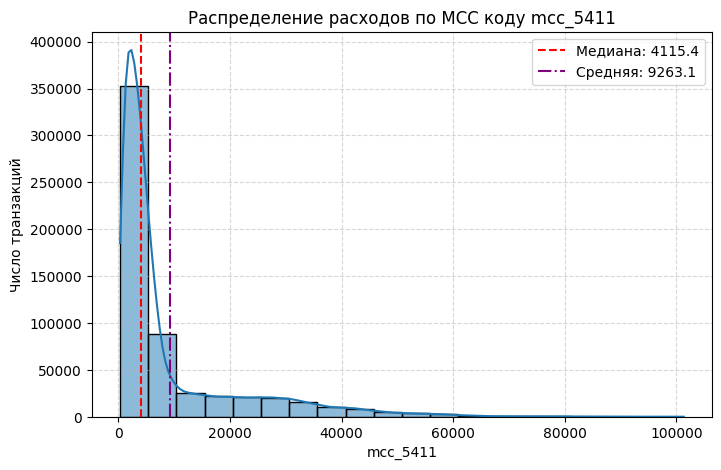

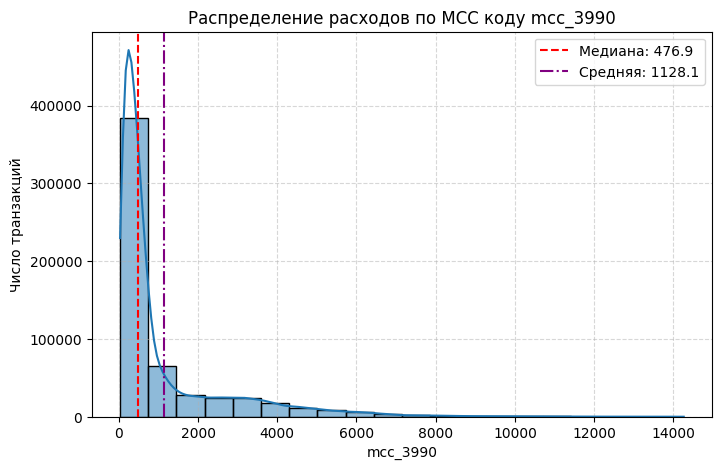

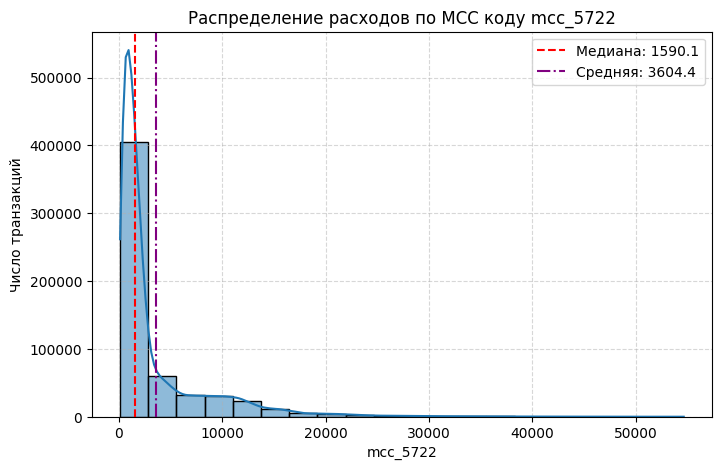

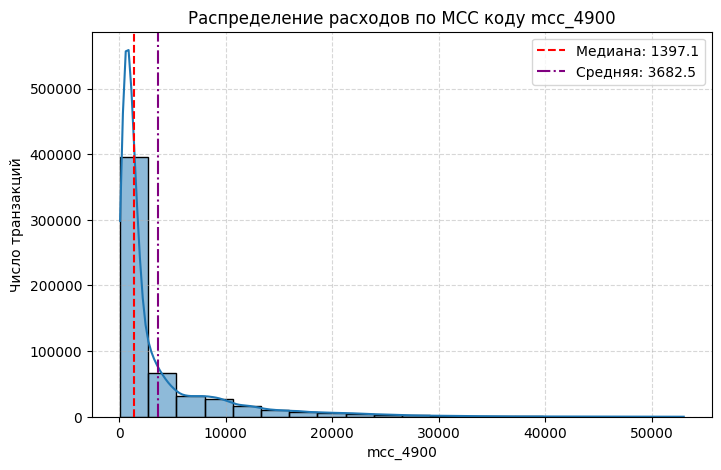

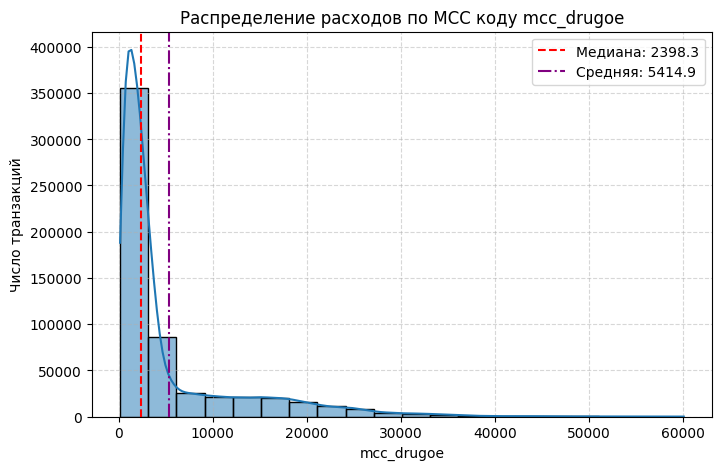

In [79]:
# histogram_chart(df=df0_loan_payment_credit, attr='prosrochka_dnej', bins=10, title_text='Распределение дней просрочки платежа', ylabel='Число дней')
for col in df0_transactions.select_dtypes(include='float').columns.to_list():
    histogram_chart(df=df0_transactions, attr=col, bins=20, figsize=(8,5), title_text=f'Распределение расходов по МСС коду {col}', ylabel='Число транзакций')

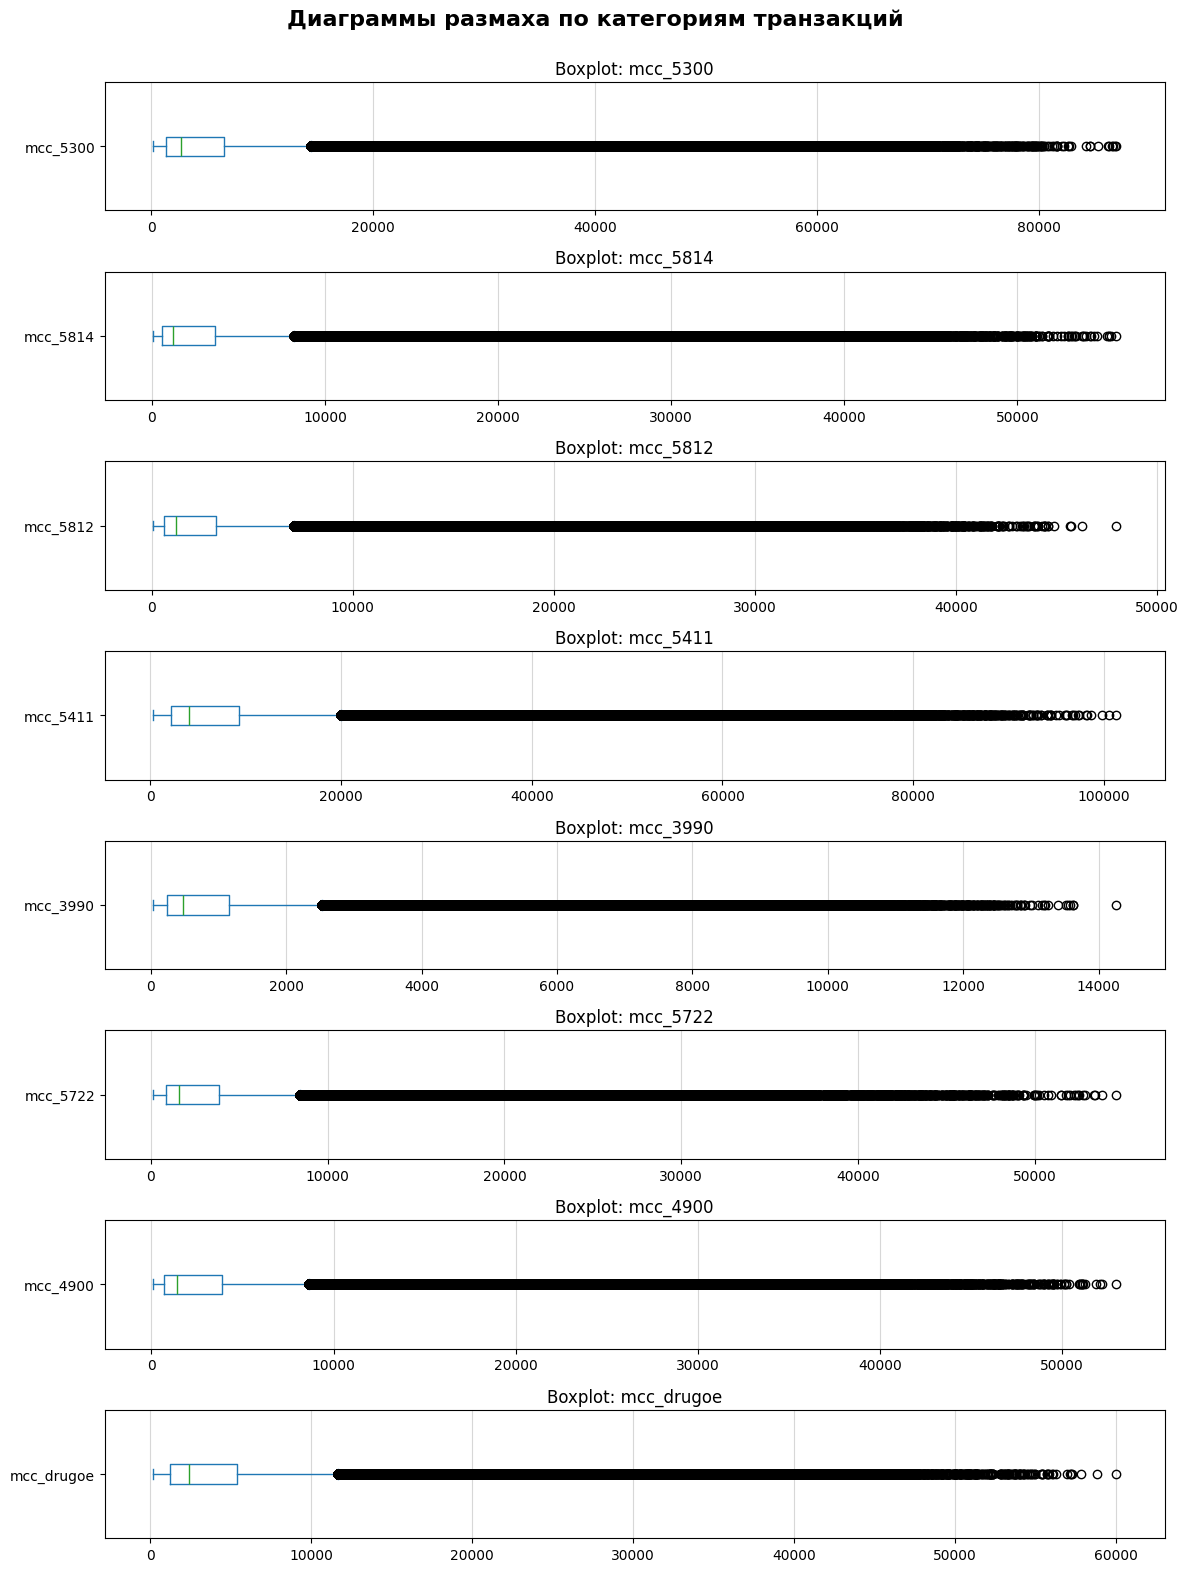

In [ ]:
boxplot_chart(
    df=df0_transactions,
    feature_list=df0_transactions.select_dtypes(include='float').columns.to_list(),
    diagram_name='Диаграммы размаха расходов по категориям транзакций'
    )

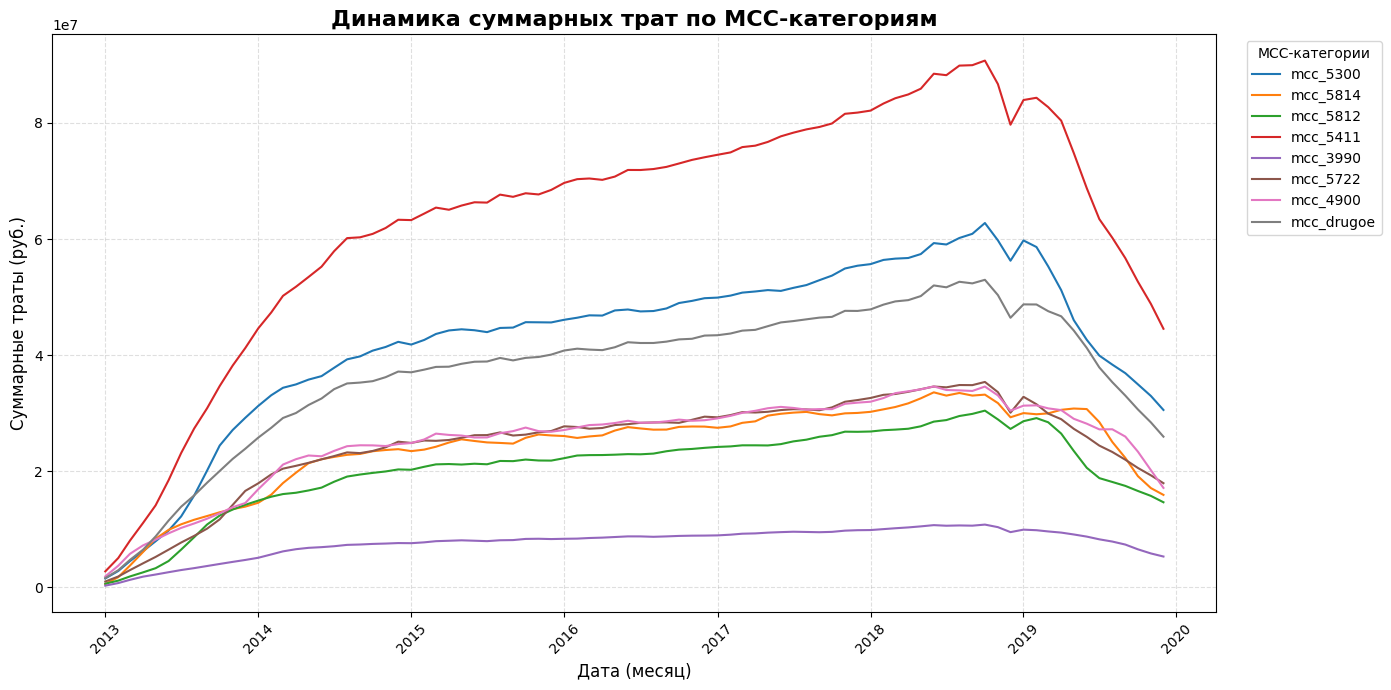

In [127]:
plot_line_time_series(
    df=df0_transactions,
    title='Динамика суммарных трат по MCC‑категориям',
    legend_title = 'MCC‑категории',
    ylabel='Суммарные траты (руб.)'
)


### 3.5 Описание клиента на момент регистрации в банке: client_description

In [90]:
df0_client_description.info()

<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id                     13500 non-null  str  
 1   vozrast                13500 non-null  int8 
 2   semejnoe_polozhenie    13500 non-null  str  
 3   nalichie_izhdivenczev  13500 non-null  int8 
 4   data_registraczii      13500 non-null  str  
dtypes: int8(2), str(3)
memory usage: 342.9 KB


In [91]:
df0_client_description.astype('str').describe()

,id,vozrast,semejnoe_polozhenie,nalichie_izhdivenczev,data_registraczii
count,13500,13500,13500,13500,13500
unique,13500,52,3,2,84
top,IDF55109846,19,нет семьи,0,2014-03-01
freq,1,357,4584,6956,189


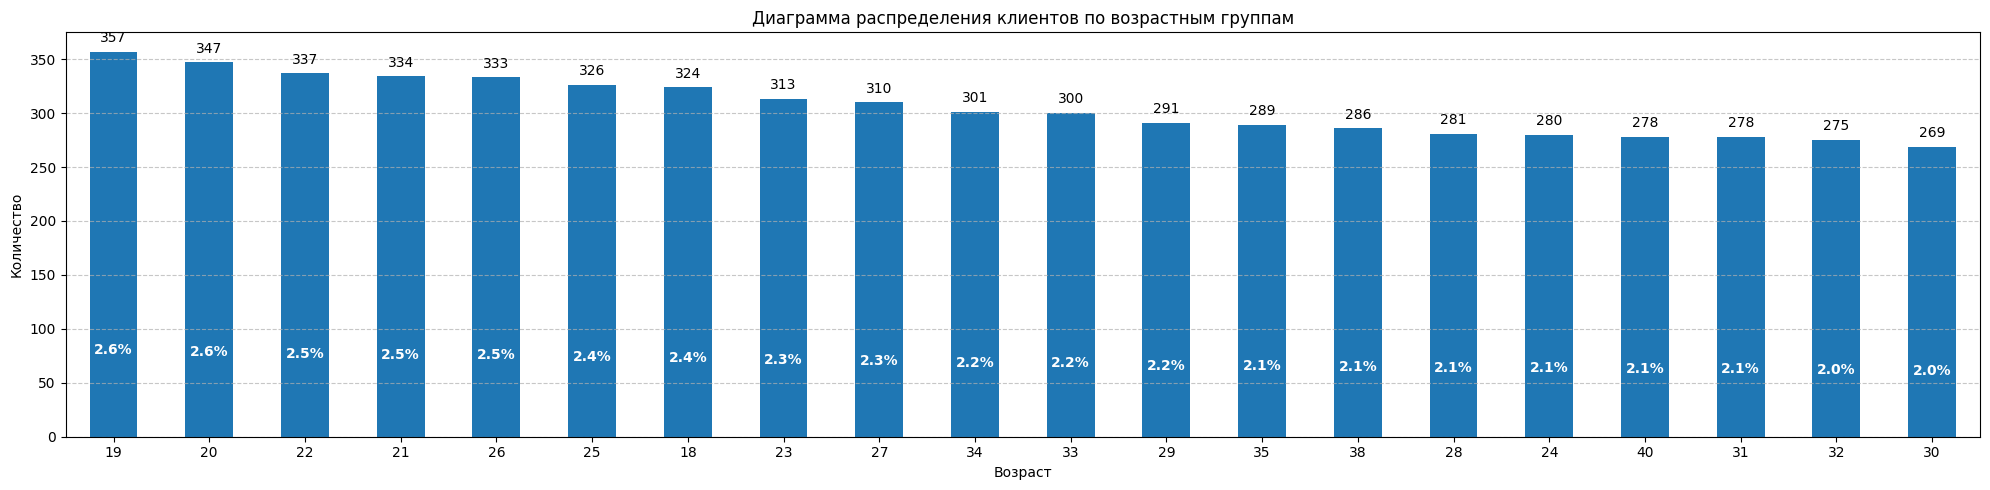

In [103]:
plot_bar_chart(df0_client_description.vozrast, xlabel='Возраст', title='Диаграмма распределения клиентов по возрастным группам', top_n=20, figsize=(20,5))

In [105]:
# Добавим признак возрастных групп
bins = [0, 25, 35, 45, 55, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56+']

df0_client_description['age_group'] = pd.cut(
    df0_client_description['vozrast'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

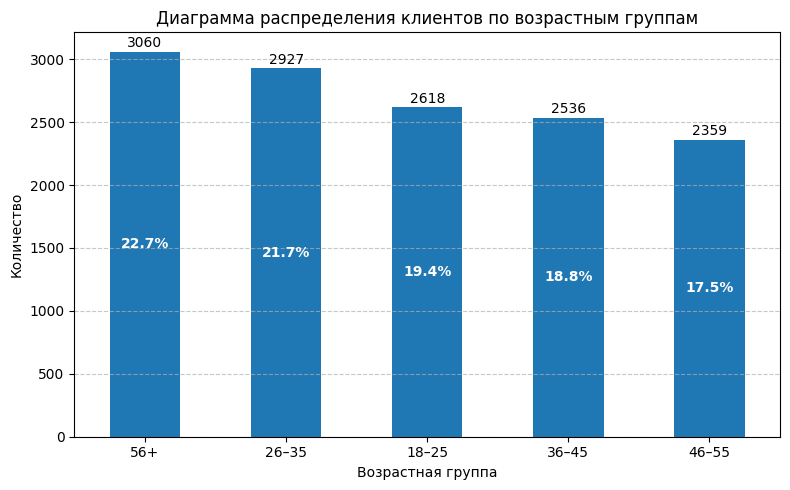

In [107]:
plot_bar_chart(df0_client_description.age_group, xlabel='Возрастная группа', title='Диаграмма распределения клиентов по возрастным группам', figsize=(8,5))

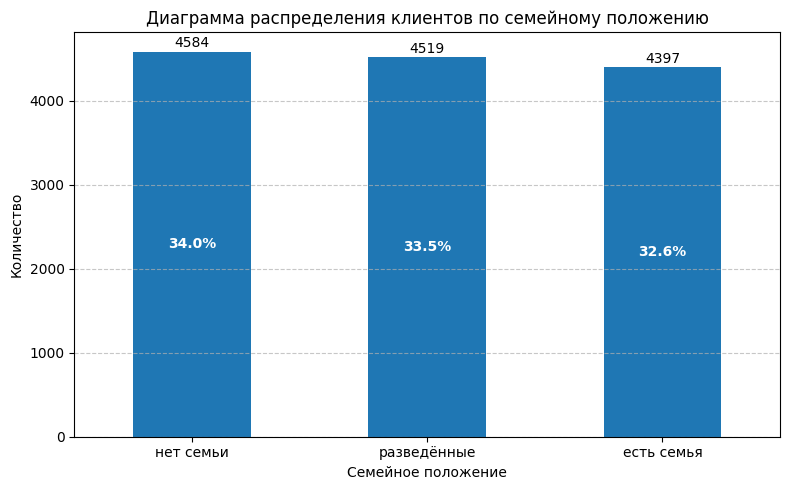

In [99]:
plot_bar_chart(df0_client_description.semejnoe_polozhenie, xlabel='Семейное положение', title='Диаграмма распределения клиентов по семейному положению', top_n=10, figsize=(8,5))

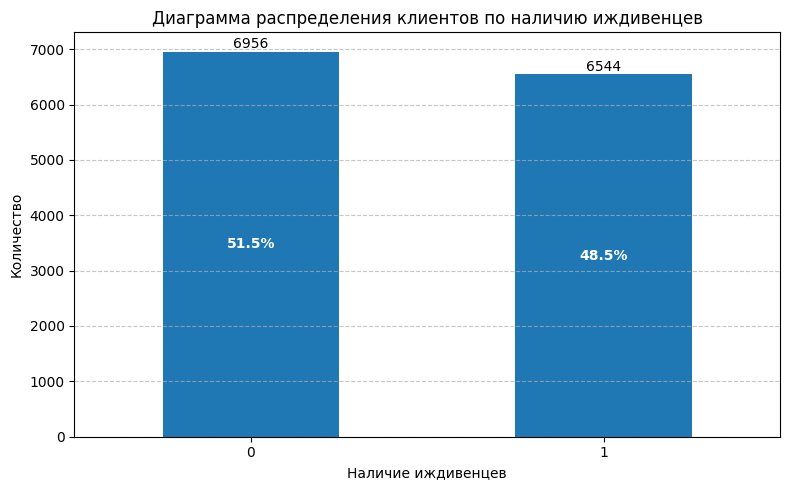

In [102]:
plot_bar_chart(df0_client_description.nalichie_izhdivenczev, xlabel='Наличие иждивенцев', title='Диаграмма распределения клиентов по наличию иждивенцев', top_n=10, figsize=(8,5))

### 3.6 Описание кредита: df0_credit_description

In [109]:
df0_credit_description.info()

<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             13500 non-null  str  
 1   dohod          13500 non-null  int32
 2   summa_kredita  13500 non-null  int32
dtypes: int32(2), str(1)
memory usage: 211.1 KB


In [112]:
with pd.option_context('display.float_format', '{:.2f}'.format):
    display(df0_credit_description.describe())

,dohod,summa_kredita
count,13500.00,13500.00
mean,79089.27,1993383.46
std,40045.55,1061381.39
min,15010.00,75000.00
25%,43347.00,1079328.75
50%,77991.50,2032732.50
75%,113615.50,2919236.25
max,149988.00,3749400.00


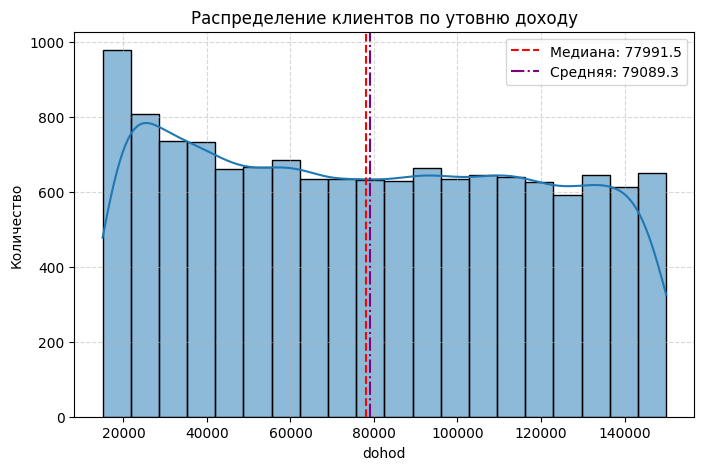

In [ ]:
histogram_chart(df=df0_credit_description, attr='dohod', bins=20, figsize=(8,5), title_text=f'Распределение клиентов по уровню доходу', ylabel='Количество')

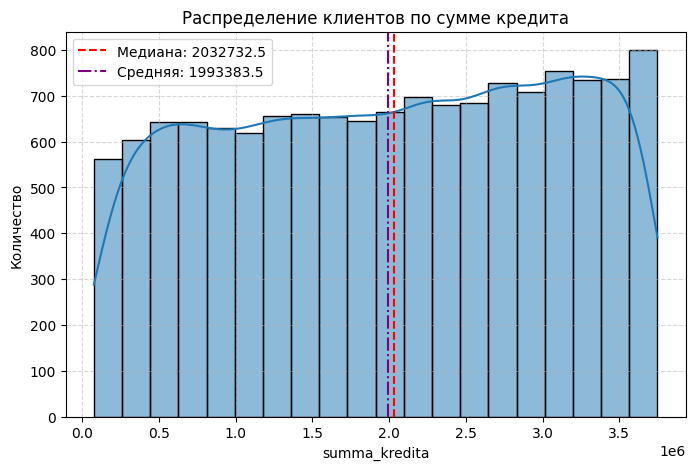

In [114]:
histogram_chart(df=df0_credit_description, attr='summa_kredita', bins=20, figsize=(8,5), title_text=f'Распределение клиентов по сумме кредита', ylabel='Количество')

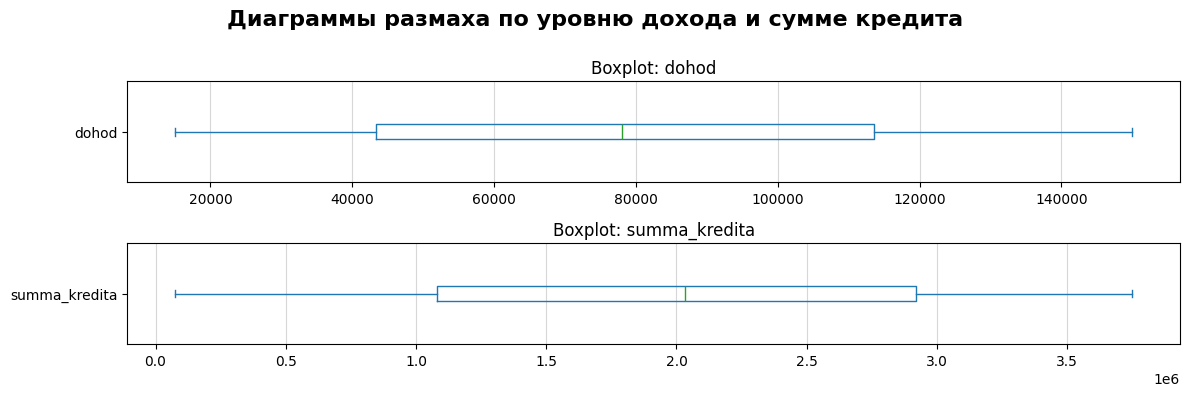

In [115]:
boxplot_chart(df=df0_credit_description, feature_list=['dohod', 'summa_kredita'], diagram_name='Диаграммы размаха по уровню дохода и сумме кредита')

### 3.7 Данные о наличии ипотеки: mortgage_presence

In [117]:
df0_mortgage_presence.info()

<class 'pandas.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                6609 non-null   str  
 1   data_otkrytiya    6609 non-null   str  
 2   nalichie_ipoteki  6609 non-null   int8 
dtypes: int8(1), str(2)
memory usage: 109.8 KB


In [119]:
print('Первая дата периода:', df0_mortgage_presence.data_otkrytiya.min())
print('последняя дата периода:', df0_mortgage_presence.data_otkrytiya.max())

Первая дата периода: 2013-01-01
последняя дата периода: 2019-12-01


In [121]:
df0_mortgage_presence.nalichie_ipoteki.value_counts()

nalichie_ipoteki
1    6609
Name: count, dtype: int64

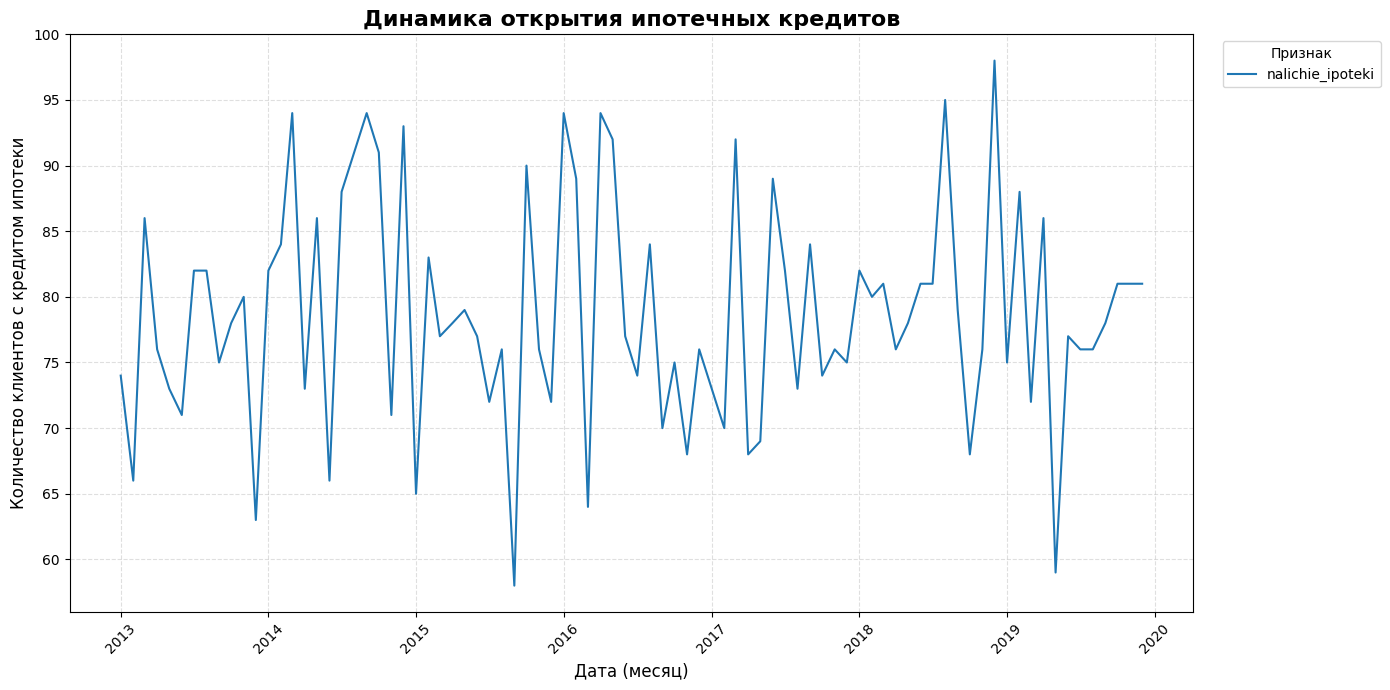

In [130]:
plot_line_time_series(
    df=df0_mortgage_presence,
    date_col='data_otkrytiya',
    cat_cols=['nalichie_ipoteki'],
    title='Динамика открытия ипотечных кредитов',
    legend_title='Признак',
    ylabel='Количество клиентов с кредитом ипотеки'
    )

### 3.8 Данные о макроэкономических показателях России: macro_data

In [132]:
df0_macro_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 84 non-null     str    
 1   uchetnaya_stavka     84 non-null     float32
 2   uroven_bezraboticzy  84 non-null     float32
 3   inflyacziya          84 non-null     float32
dtypes: float32(3), str(1)
memory usage: 1.8 KB


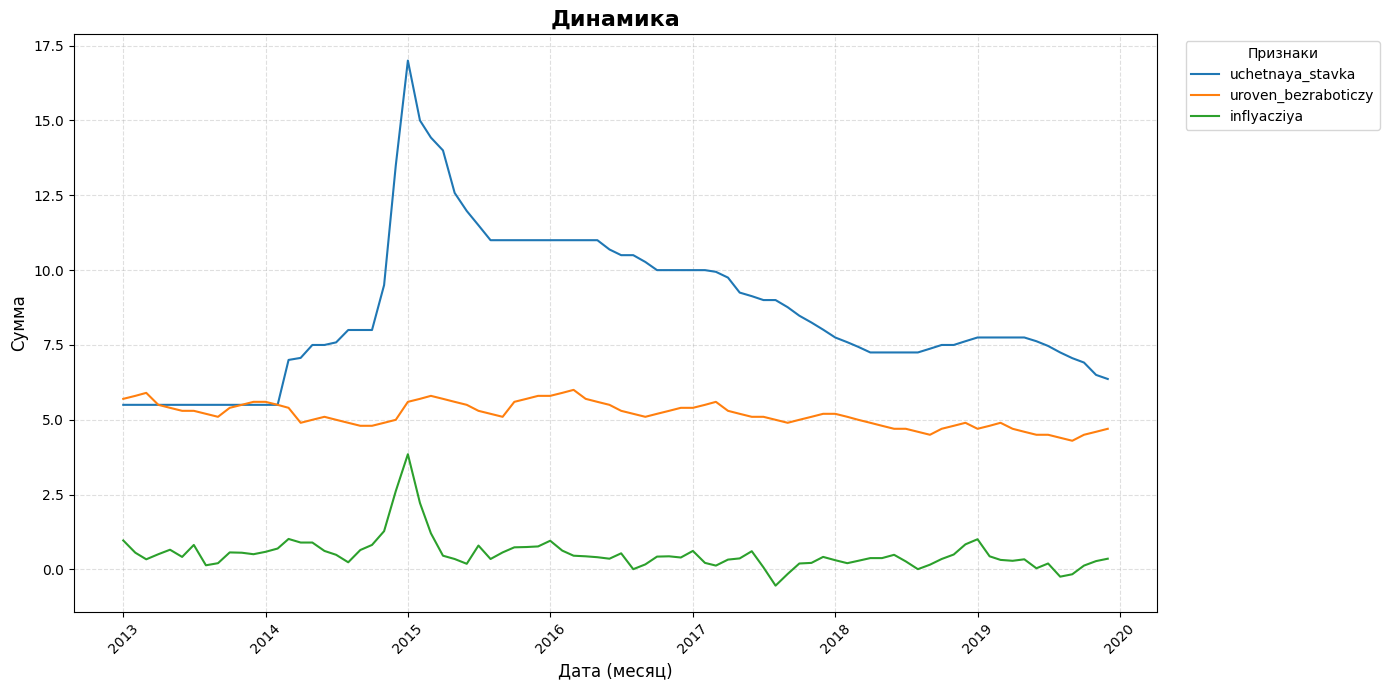

In [134]:
plot_line_time_series(df=df0_macro_data, date_col='date', cat_cols=None, legend_title='Признаки')

###  Данные о дате проведения поведенческого скоринга: cohort_grid

In [136]:
df0_cohort_grid.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   id          577494 non-null  str  
 1   score_date  577494 non-null  str  
dtypes: str(2)
memory usage: 8.8 MB


In [138]:
df0_cohort_grid.describe()

,id,score_date
count,577494,577494
unique,13500,84
top,IDF55014574,2019-12-01
freq,84,13500


## Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.

## Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.

